### Converting the Original COCO Data to YOLO format
**Deprecated**

In [1]:
import ultralytics
from ultralytics import YOLO
import os 
import shutil

In [6]:
from ultralytics.data.converter import convert_coco

data_path = '/leopard.coco/leopard.coco'

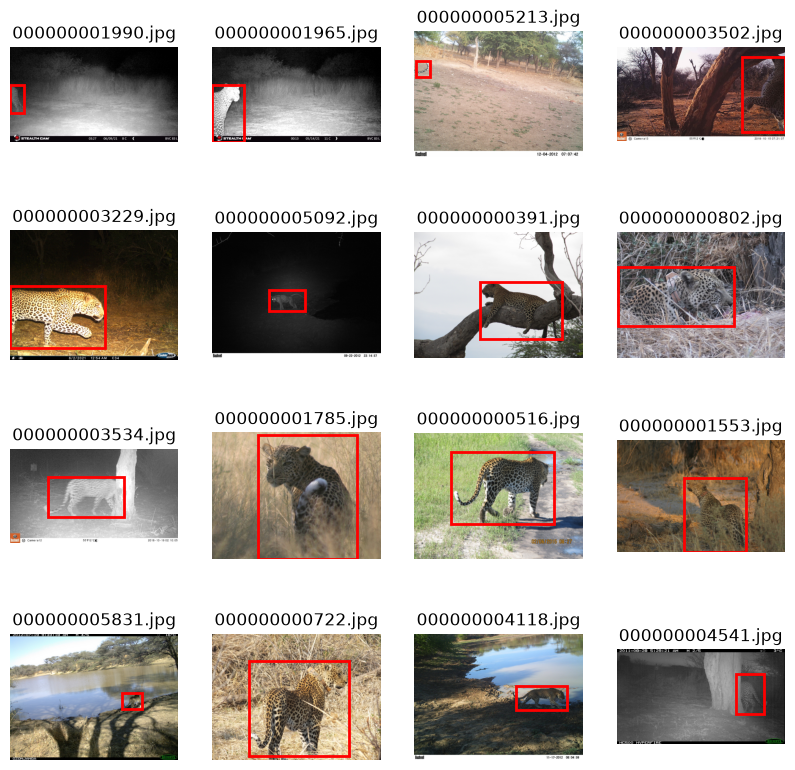

In [ ]:
# Display random 16 images from the dataset
# \yolo_leopard_dataset\train\images

import random
import matplotlib.pyplot as plt

data_path = 'data/v1_yolo_dataset/'

#start plotting

plt.figure(figsize=(10, 10))

for i in range(16):
    # Randomly select an image from the dataset
    img_path = random.choice(os.listdir(data_path))
    img_full_path = os.path.join(data_path, img_path)
    
    # Load and display the image
    img = plt.imread(img_full_path)
    plt.subplot(4, 4, i + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(img_path)


#Draw bounding boxes on the images

for i in range(16):
    # Randomly select an image from the dataset
    img_path = random.choice(os.listdir(data_path))
    img_full_path = os.path.join(data_path, img_path)
    
    # Load and display the image
    img = plt.imread(img_full_path)
    plt.subplot(4, 4, i + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(img_path)
    
    # Load the corresponding annotation file
    annotation_file = img_path.replace('.jpg', '.txt')  # Assuming annotations are in .txt format
    annotation_path = os.path.join(data_path.replace('images', 'labels'), annotation_file)
    
    if os.path.exists(annotation_path):
        with open(annotation_path, 'r') as f:
            for line in f:
                class_id, x_center, y_center, width, height = map(float, line.strip().split())
                
                # Convert normalized coordinates to pixel values
                img_height, img_width, _ = img.shape
                x_center *= img_width
                y_center *= img_height
                width *= img_width
                height *= img_height
                
                # Calculate top-left corner of the bounding box
                x_min = int(x_center - width / 2)
                y_min = int(y_center - height / 2)
                
                # Draw the bounding box on the image
                rect = plt.Rectangle((x_min, y_min), width, height, edgecolor='red', facecolor='none', linewidth=2)
                plt.gca().add_patch(rect)
    

In [9]:
import json
import os
import shutil
import glob
from sklearn.model_selection import train_test_split

# 1. Define local dataset paths
base_path = "leopard.coco"  # Main extracted dataset folder
annotations_dir = os.path.join(base_path, "annotations")
images_src_dir = os.path.join(base_path, "images", "train2022")

# Look specifically for the training JSON file to avoid empty test/val JSONs
json_files = glob.glob(os.path.join(annotations_dir, "*train*.json"))

# Fallback: if no file has 'train' in its name, look for any JSON
if not json_files:
    json_files = glob.glob(os.path.join(annotations_dir, "*.json"))

if not json_files:
    raise FileNotFoundError(f"❌ No JSON annotation file found in: {os.path.abspath(annotations_dir)}")

# Select the valid training JSON file
json_path = json_files[0]
print(f" Found valid JSON file: {os.path.basename(json_path)}")

# Define output directory for the formatted YOLO dataset
output_base = "yolo_leopard_dataset"
for split in ['train', 'val']:
    os.makedirs(os.path.join(output_base, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(output_base, split, 'labels'), exist_ok=True)

# 2. Load the combined COCO JSON dataset
with open(json_path, 'r', encoding='utf-8') as f:
    coco_data = json.load(f)

# Guard clause to ensure we didn't accidentally load an empty file
if not coco_data.get('images'):
    raise ValueError("❌ Loaded JSON file contains 0 images. Please ensure the file is not empty.")

print(f"Total images in JSON: {len(coco_data['images'])}")
print(f"Total annotations in JSON: {len(coco_data['annotations'])}")

# 3. Split images into 80% Training and 20% Validation
train_imgs, val_imgs = train_test_split(coco_data['images'], test_size=0.2, random_state=42)

# Map image IDs to their respective info dictionaries for faster O(1) lookups
train_img_ids = {img['id']: img for img in train_imgs}
val_img_ids = {img['id']: img for img in val_imgs}

# 4. Core function to process annotations, convert coordinates, and save to YOLO format
def process_split(annotations, target_img_dict, split_name):
    count_saved = 0
    
    # Group annotations by image_id to optimize processing loop
    img_to_anns = {}
    for ann in annotations:
        img_id = ann['image_id']
        if img_id in target_img_dict:
            img_to_anns.setdefault(img_id, []).append(ann)
            
    # Iterate through each image in the split target dictionary
    for img_id, img_info in target_img_dict.items():
        img_filename = img_info['file_name']
        
        # Skip macOS hidden metadata files if present by mistake
        if img_filename.startswith('._'):
            continue
            
        src_img_path = os.path.join(images_src_dir, img_filename)
        
        # Verify that the physical image file exists on the disk
        if not os.path.exists(src_img_path):
            continue
            
        # Copy the image file to the corresponding YOLO split folder
        dst_img_path = os.path.join(output_base, split_name, 'images', img_filename)
        shutil.copy(src_img_path, dst_img_path)
        
        # Prepare the corresponding text file for YOLO annotations [class_id x_center y_center width height]
        txt_filename = os.path.splitext(img_filename)[0] + '.txt'
        txt_dst_path = os.path.join(output_base, split_name, 'labels', txt_filename)
        
        img_w = img_info['width']
        img_h = img_info['height']
        
        with open(txt_dst_path, 'w') as txt_file:
            ann_list = img_to_anns.get(img_id, [])
            for ann in ann_list:
                # Default class ID is 0 for 'leopard' in this custom dataset
                class_id = 0 
                
                # COCO format: [x_min, y_min, width, height] (absolute values in pixels)
                bbox = ann['bbox']
                x_min, y_min, w, h = bbox[0], bbox[1], bbox[2], bbox[3]
                
                # Convert COCO absolute pixels to normalized YOLO format (relative 0.0 to 1.0)
                x_center = (x_min + w / 2.0) / img_w
                y_center = (y_min + h / 2.0) / img_h
                w_norm = w / img_w
                h_norm = h / img_h
                
                # Write the bounding box annotation to the text file
                txt_file.write(f"{class_id} {x_center:.6f} {y_center:.6f} {w_norm:.6f} {h_norm:.6f}\n")
                
        count_saved += 1
    print(f"Successfully processed {count_saved} images for '{split_name}' split.")

# Run the processing pipeline for both training and validation sets
process_split(coco_data['annotations'], train_img_ids, 'train')
process_split(coco_data['annotations'], val_img_ids, 'val')

# 5. Automatically generate the data.yaml configuration file required by YOLO
yaml_path = os.path.join(output_base, "data.yaml")
yaml_content = f"""
path: {os.path.abspath(output_base)}
train: train/images
val: val/images

names:
  0: leopard
"""

with open(yaml_path, "w", encoding='utf-8') as f:
    f.write(yaml_content.strip())

print(f"\n Generated data.yaml successfully at: {os.path.abspath(yaml_path)}")
print(" Processing finished! Your dataset is successfully converted and ready for the Baseline model.")

 Found valid JSON file: instances_train2022.json
Total images in JSON: 6795
Total annotations in JSON: 6825
Successfully processed 5436 images for 'train' split.
Successfully processed 1359 images for 'val' split.

 Generated data.yaml successfully at: c:\Users\Abdullah_Laptop\Desktop\KAUST SUMMER\Project\yolo_leopard_dataset\data.yaml
 Processing finished! Your dataset is successfully converted and ready for the Baseline model.


In [5]:
#Now that you have train/val splits, we need to create a seperate test split.
# take the images from the val set with their labels and make it the same in size as the validation split.
#exactly half of the validation split will be used for testing. The other half will remain as validation.

#code goes here:

import os
import shutil
import random

# 1. Define base directory paths
val_dir = "yolo_leopard_dataset/val"
test_dir = "yolo_leopard_dataset/test"

# Define explicit subdirectories for both splits
val_images_dir = os.path.join(val_dir, "images")
val_labels_dir = os.path.join(val_dir, "labels")

test_images_dir = os.path.join(test_dir, "images")
test_labels_dir = os.path.join(test_dir, "labels")

# CRITICAL FIX: Ensure all target subdirectories are physically created on Windows
os.makedirs(test_images_dir, exist_ok=True)
os.makedirs(test_labels_dir, exist_ok=True)

# 2. Get all images in the validation folder
all_images = [f for f in os.listdir(val_images_dir) if not f.startswith('._')]

# 3. Randomly select exactly half of the images for testing
num_test_files = len(all_images) // 2
random.seed(42)  # Set seed for reproducibility
test_images_pool = random.sample(all_images, num_test_files)

print(f"Total validation images found: {len(all_images)}")
print(f"Moving {num_test_files} pairs to the test split...")

# 4. Core loop to move matched pairs (Image + Label) simultaneously
moved_count = 0
for img_name in test_images_pool:
    # Construct source and destination paths for the image
    src_img_path = os.path.join(val_images_dir, img_name)
    dst_img_path = os.path.join(test_images_dir, img_name)
    
    # Construct corresponding source and destination paths for the label (.txt)
    base_name = os.path.splitext(img_name)[0]
    label_name = base_name + ".txt"
    src_label_path = os.path.join(val_labels_dir, label_name)
    dst_label_path = os.path.join(test_labels_dir, label_name)
    
    # Verify that both the image and its corresponding label exist before moving
    if os.path.exists(src_img_path) and os.path.exists(src_label_path):
        shutil.move(src_img_path, dst_img_path)
        shutil.move(src_label_path, dst_label_path)
        moved_count += 1

print(f"Successfully moved {moved_count} image-label pairs to '{test_dir}'.")
print(f"Remaining images in validation: {len(os.listdir(val_images_dir))}")

Total validation images found: 1358
Moving 679 pairs to the test split...
Successfully moved 679 image-label pairs to 'yolo_leopard_dataset/test'.
Remaining images in validation: 679


In [12]:
model = YOLO('yolov8s.pt')

In [17]:
#train the model

model.train(
    data='yolo_leopard_dataset/data.yaml',
    epochs= 2,
)

Ultralytics 8.4.84  Python-3.14.5 torch-2.12.1+cpu CPU (Intel Core Ultra 7 155H)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_leopard_dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=2, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=

KeyboardInterrupt: 

### Run model predictions on the images folder

In [ ]:
from ultralytics import YOLO
import shutil
import os

# 1. Run prediction (creates runs/detect/v1_model/predictions)
model.predict(
    source='data/backups/Arabian Leopard', 
    save=True, 
    project='runs/detect/v1_model', 
    name='predictions', 
    exist_ok=True
)

# 2. Move the folder to root level v1_model/
os.makedirs('v1_model', exist_ok=True)
shutil.move('runs/detect/v1_model/predictions', 'v1_model/predictions')

# 3. Clean up the empty runs/ directory
shutil.rmtree('runs')

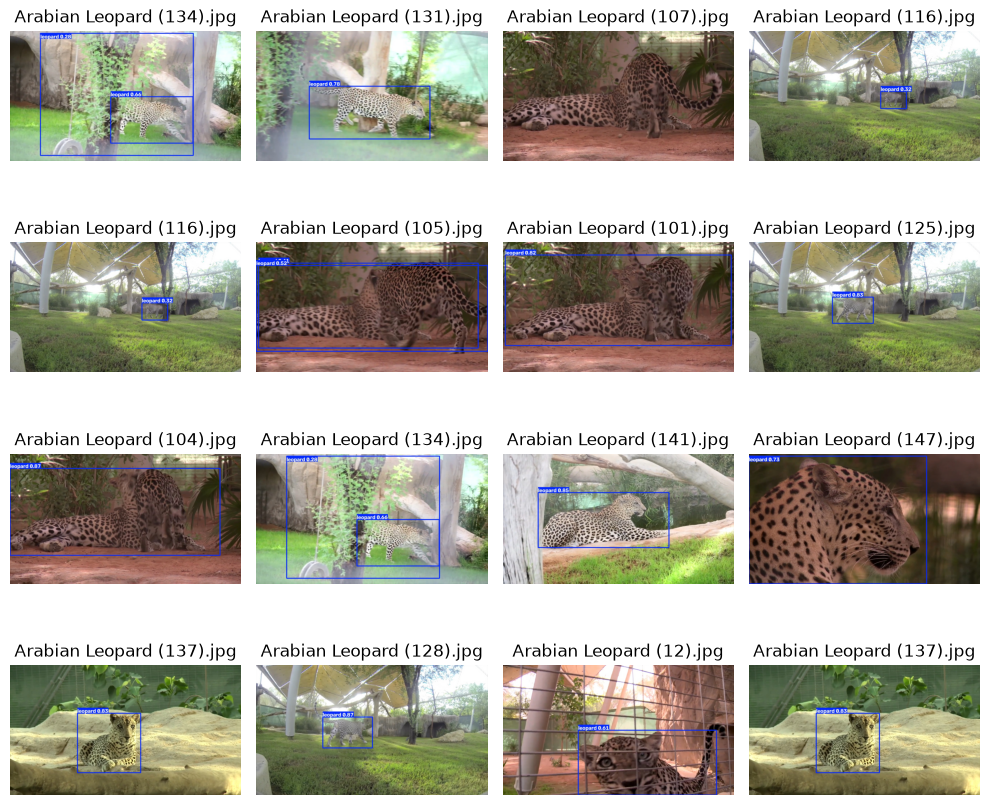

In [3]:
# Display random 16 images from the predictions folder
predictions_path = 'v1_model/predictions'

import random 
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for i in range(16):
    # Randomly select an image from the predictions folder
    img_path = random.choice(os.listdir(predictions_path))
    img_full_path = os.path.join(predictions_path, img_path)
    
    # Load and display the image
    img = plt.imread(img_full_path)
    plt.subplot(4, 4, i + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(img_path)
    plt.tight_layout()
plt.show()

#### Run the model on camera to capture live input

In [ ]:
from ultralytics import YOLO
import cv2
import time

# 1. Load the model
model_path = 'v1_model/weights/best.pt'
model = YOLO(model_path)

# 2. Start the webcam
cap = cv2.VideoCapture(0)

print("Webcam started. Press 'q' to quit.")

while cap.isOpened():
    success, frame = cap.read()
    if not success:
        print("Failed to grab frame from webcam.")
        break

    # --- LATENCY TRACKING START ---
    start_time = time.time()

    # 3. Run YOLO inference on the current frame
    results = model.predict(frame, conf=0.25, verbose=False)

    end_time = time.time()
    # Calculate overall latency in milliseconds
    latency_ms = (end_time - start_time) * 1000
    # --- LATENCY TRACKING END ---

    # 4. Extract detailed internal speeds from YOLO (optional but highly accurate)
    # YOLO breaks down speed into preprocess, inference, and postprocess keys
    yolo_speed = results[0].speed
    inference_ms = yolo_speed.get('inference', 0.0)

    # 5. Print the latency metrics to the terminal
    print(f"Total Step Latency: {latency_ms:.2f} ms | Pure Inference Latency: {inference_ms:.2f} ms")

    # 6. Visualize the results
    annotated_frame = results[0].plot()

    # Optional: Draw the latency directly onto the video frame window
    cv2.putText(
        annotated_frame, 
        f"Inference: {inference_ms:.1f}ms", 
        (10, 30), 
        cv2.FONT_HERSHEY_SIMPLEX, 
        1, 
        (0, 255, 0), 
        2, 
        cv2.LINE_AA
    )

    # 7. Display the frame in a window
    cv2.imshow("Leopard Detector - Live Test", annotated_frame)

    # 8. Break the loop if the 'q' key is pressed
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

# Clean up
cap.release()
cv2.destroyAllWindows()

Webcam started. Press 'q' to quit.
Total Step Latency: 220.52 ms | Pure Inference Latency: 143.96 ms
Total Step Latency: 94.40 ms | Pure Inference Latency: 91.39 ms
Total Step Latency: 100.74 ms | Pure Inference Latency: 97.96 ms
Total Step Latency: 78.05 ms | Pure Inference Latency: 74.11 ms
Total Step Latency: 91.59 ms | Pure Inference Latency: 88.86 ms
Total Step Latency: 96.34 ms | Pure Inference Latency: 92.38 ms
Total Step Latency: 93.86 ms | Pure Inference Latency: 89.89 ms
Total Step Latency: 89.80 ms | Pure Inference Latency: 86.78 ms
Total Step Latency: 87.76 ms | Pure Inference Latency: 84.91 ms
Total Step Latency: 85.96 ms | Pure Inference Latency: 83.70 ms
Total Step Latency: 83.89 ms | Pure Inference Latency: 80.53 ms
Total Step Latency: 67.56 ms | Pure Inference Latency: 64.49 ms
Total Step Latency: 74.71 ms | Pure Inference Latency: 71.55 ms
Total Step Latency: 75.45 ms | Pure Inference Latency: 72.60 ms
Total Step Latency: 67.15 ms | Pure Inference Latency: 64.24 ms
To